<a href="https://colab.research.google.com/github/shriyaraja/FM-models/blob/main/Lab3a_Shriya_Raja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=green> Climate, Water, and the Environment, Spring 2026

### Lab 3 Week 2 - Watershed Mass Balance, Real-World Catchment Data

---


## <font color=red> Your name: Shriya Raja

## Tracking watershed mass balance

*In this notebook you will learn how to*
- Use mass balance to track water storage in a watershed
- Evaluate the assumption of no storage between water years
- Compare water storage between two different watersheds to generate hypotheses on what might control water storage

You will also see the following Python scientific packages that help make handling time series data easier:

`numpy .where`

`pandas .groupby`

`pandas .cumsum.`

In [ ]:
# Import required libraries. Must run this first

import matplotlib.pyplot as plt
# Importing the pandas library, which provides powerful tools for data analysis and manipulation
import pandas as pd
import numpy as np
%matplotlib inline

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",category=DeprecationWarning) #ignores deprecation warnings

from datetime import datetime, date #we will use this to manipulate dates in our time series


# Read in Data
We will work with real data from two watersheds in Northern California: Elder Creek and Dry Creek. More information about these watersheds can be found in [Hahm et al., 2019.](https://czo-archive.criticalzone.org/images/national/associated-files/Hahm_et_al._2019_Water_Resources_Research.pdf)

We will read in precipitation, streamflow and potential evapotranspiration ($PET$) as an approximation for actual evapotranspiration ($AET$, which is really hard to measure).


The precipitation and streamflow data come from a published paper: Dralle et al., 2018:
The paper is [here](https://onlinelibrary.wiley.com/doi/full/10.1002/hyp.11627?casa_token=agl0YyWQCcAAAAAA%3A6ngqWjLSXqBcNk3UlDDLojIXWqFonNK84_G0qT5ZTHyEBBmGcKx4qnL_1CcpxMfZ6-ptlytM5liL-lc) and the data are [here](https://github.com/daviddralle/indirect_storage)

We will download the data from Dralle et al., 2018.
*This could take a couple of seconds.*

In [ ]:
# ## q is runoff in m/day (i.e., the discharge has been divided by the drainage area)
# Load runoff data for the Dry Creek watershed, where the discharge has been normalized by the drainage area.
# The data is loaded from a CSV file available online, and the first column is used as the index (the date).
# parse_dates=True tells pandas to automatically parse the date column into a DateTime format.
dry_q_mmday = pd.read_csv('https://daviddralle.github.io/teaching_data/dry_discharge_daily.csv',
                          index_col=0, parse_dates=True)

# Similarly, load runoff data for the Elder Creek watershed. This is also normalized by the drainage area.
elder_q_mmday = pd.read_csv('https://daviddralle.github.io/teaching_data/elder_discharge_daily.csv',
                            index_col=0, parse_dates=True)

# ## ppt (precipitation) is in mm/day
# Load precipitation data (in millimeters per day) from an online CSV file.
# The data has multiple columns, so index_col=0 ensures that the date column is used as the index.
# parse_dates=True converts the date column to DateTime format, and skiprows=[0]
# skips the first row (often metadata or headers).
ppt = pd.read_csv('https://raw.githubusercontent.com/daviddralle/storage_cvs/master/data/elder_dry_prism_ppt.csv',
                  index_col=0, parse_dates=True, skiprows=[0])

# Extract the precipitation data specifically for Elder Creek, using double
# brackets to keep the result as a DataFrame.
elder_ppt_mm_day = ppt[['Elder Creek']].copy()

# Rename the column from 'Elder Creek' to 'ppt' (short for precipitation) to make the data easier to work with later.
elder_ppt_mm_day = elder_ppt_mm_day.rename(columns={'Elder Creek': 'ppt'})

# Use Elder Creek's precipitation data for both Dry Creek and Elder Creek.
# This assumes that the same precipitation data applies to both watersheds.
dry_ppt_mm_day = ppt[['Elder Creek']].copy()
dry_ppt_mm_day = dry_ppt_mm_day.rename(columns={'Elder Creek': 'ppt'})

# ## pet (potential evapotranspiration) is in mm/day
# Load potential evapotranspiration (PET) data for the Dry Creek watershed in
# millimeters per day. PET represents the amount of water that could be
# evaporated and transpired if there was enough moisture available.
dry_pet_mmday = pd.read_csv('https://daviddralle.github.io/teaching_data/dry_pet_daily.csv',
                            index_col=0, parse_dates=True)

# Similarly, load potential evapotranspiration data for the Elder Creek watershed.
elder_pet_mmday = pd.read_csv('https://daviddralle.github.io/teaching_data/elder_pet_daily.csv',
                              index_col=0, parse_dates=True)


# Evaluate differences in the hydrographs across Elder and Dry Creek
   
    


Let's look at the precipitation and PET data. **What similarities and differences do you notice between the two sites?**

<font color=red> Elder Creek as more vegetation and therefore might be able to absorb more water, whereas Dry Creek, as the name suggests, is drier and has less vegetation coverage.

Remember that PET is the amount of water that *could be* evapotranspired if there was sufficient water and is calculated based on temperature, solar radiation, wind speed, and humidity.

Mediterranean climates are characterized by rainfall delivery that is out of phase with evapotranspiration. **Do you see evidence of that in your data?**

<font color=red> Yes, this is seen in the way precipitation is highest when evapotranspiration is lowest.


(16709.0, 17440.0)

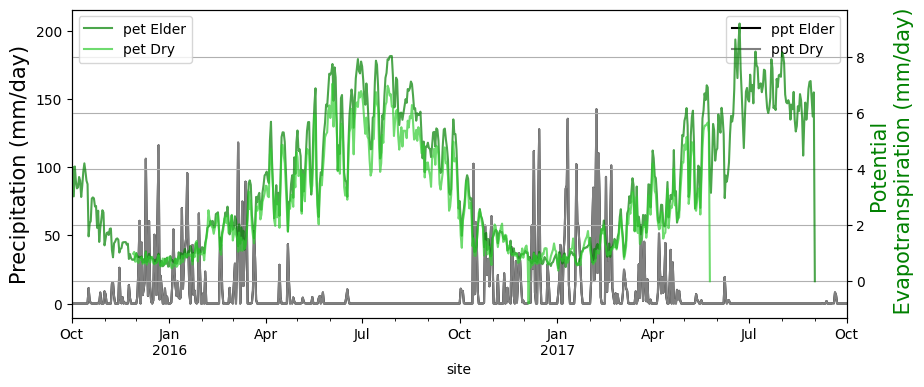

In [ ]:

# Create a plot that shows both precipitation (ppt) and potential evapotranspiration (PET) for both Elder Creek and Dry Creek

# Create a figure and axis, sharing the same x-axis
fig, ax = plt.subplots(sharex=True)

# Plot precipitation (ppt) data for Elder Creek in black
elder_ppt_mm_day.plot(kind='line', figsize=(10,4), color='black', ax=ax, label='ppt elder')

# Plot precipitation (ppt) data for Dry Creek in gray on the same axis
dry_ppt_mm_day.plot(kind='line', figsize=(10,4), color='gray', ax=ax, label='ppt dry')

# Set the y-axis label for the primary plot (precipitation in mm/day)
ax.set_ylabel('Precipitation (mm/day)', color='black', fontsize=15)

# Add a legend to identify the precipitation plots
ax.legend(['ppt Elder', 'ppt Dry'])

# Create a twin axis on the right side of the plot for potential evapotranspiration (PET) data
# This allows plotting two different variables (ppt and PET) on the same x-axis but with two separate y-axes
ax2 = ax.twinx()

# Plot PET (potential evapotranspiration) data for Elder Creek in green on the secondary y-axis
elder_pet_mmday.plot(kind='line', figsize=(10,4), color='green', ax=ax2, label='pet elder', alpha=0.7)

# Plot PET data for Dry Creek in limegreen on the same secondary y-axis
dry_pet_mmday.plot(kind='line', figsize=(10,4), color='limegreen', ax=ax2, label='pet dry', alpha=0.7)

# Set the y-axis label for the secondary y-axis (PET in mm/day)
ax2.set_ylabel('Potential \n Evapotranspiration (mm/day)', color='green', fontsize=15)

# Add a legend to identify the PET plots
ax2.legend(['pet Elder', 'pet Dry'])

# Add a grid for the secondary y-axis
ax2.grid()

# Set the same x-axis limits (date range) for the secondary y-axis to match the precipitation data
ax.set_xlim(date(2015, 10, 1), date(2017, 10, 1))  # Make sure the x-axis dates match across all plots

Let's look at the discharge data. **What similarities and differences do you expect to see? How do the discharge time series (i.e. hydrographs) compare to your hypotheses?**

(16709.0, 17440.0)

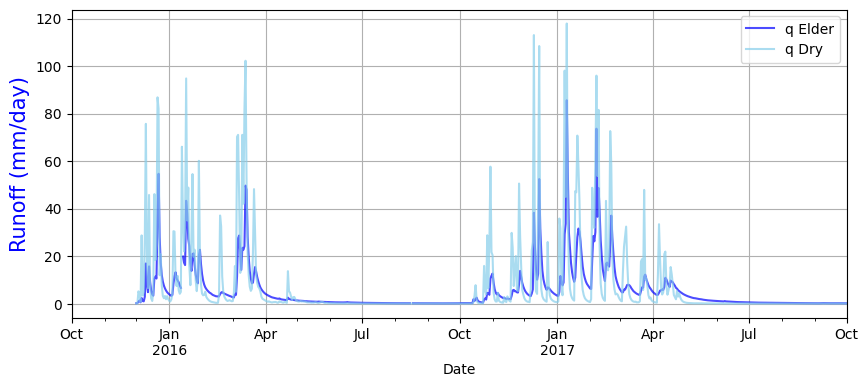

In [ ]:

# Create the first plot for runoff (q) for both Elder Creek and Dry Creek
fig, ax = plt.subplots(sharex=True)  # Create a figure and an axis. 'sharex=True' makes them share the same x-axis

# Plot runoff (q) data for Elder Creek in blue
elder_q_mmday.plot(kind='line', figsize=(10,4), color='blue', ax=ax, label='q elder', alpha=0.7)

# Plot runoff (q) data for Dry Creek in skyblue on the same axis
dry_q_mmday.plot(kind='line', figsize=(10,4), color='skyblue', ax=ax, label='q dry', alpha=0.7)

# Set the y-axis label for the primary plot (runoff in mm/day)
ax.set_ylabel('Runoff (mm/day)', color='blue', fontsize=15)

# Add a legend to identify the plots
ax.legend(['q Elder', 'q Dry'])

# Add a grid to the plot for better readability
ax.grid()

# Set the x-axis limits (i.e., the time period shown on the x-axis)
# The 'date()' function from the 'datetime' module defines the start and end date (from Oct 2015 to Oct 2017)
ax.set_xlim(date(2015, 10, 1), date(2017, 10, 1))  # Be careful with date formats, as they can be tricky to handle


### <font color= orange> Task: modify the code above to generate a hydrograph at the storm time scale

Zooming in on first peak of discharge



- <font color = orange> HINT: look at how the dates are formatted in the above code cell (i.e., the xaxis)

(16770.0, 16801.0)

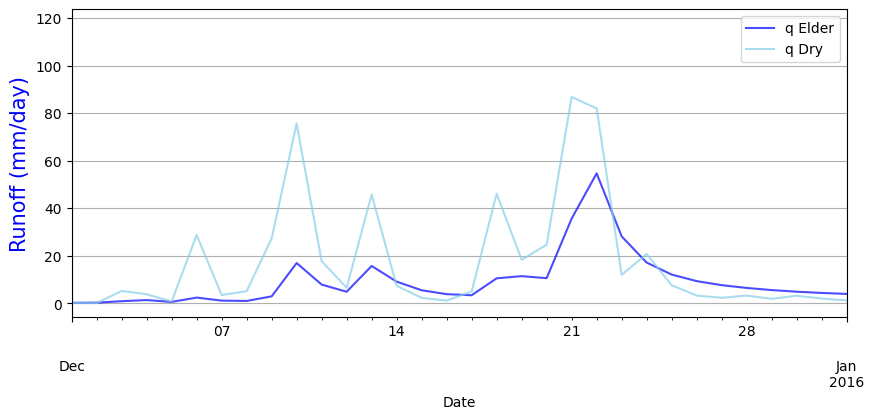

In [ ]:
# Create the first plot for runoff (q) for both Elder Creek and Dry Creek
fig, ax = plt.subplots(sharex=True)  # Create a figure and an axis. 'sharex=True' makes them share the same x-axis

# Plot runoff (q) data for Elder Creek in blue
elder_q_mmday.plot(kind='line', figsize=(10,4), color='blue', ax=ax, label='q elder', alpha=0.7)

# Plot runoff (q) data for Dry Creek in skyblue on the same axis
dry_q_mmday.plot(kind='line', figsize=(10,4), color='skyblue', ax=ax, label='q dry', alpha=0.7)

# Set the y-axis label for the primary plot (runoff in mm/day)
ax.set_ylabel('Runoff (mm/day)', color='blue', fontsize=15)

# Add a legend to identify the plots
ax.legend(['q Elder', 'q Dry'])

# Add a grid to the plot for better readability
ax.grid()

# Set the x-axis limits (i.e., the time period shown on the x-axis)
# The 'date()' function from the 'datetime' module defines the start and end date (from Oct 2015 to Oct 2017)
ax.set_xlim(date(2015, 12, 1), date(2016, 1, 1))  # Be careful with date formats, as they can be tricky to handle


# Perform an annual water balance for Elder Creek and Dry Creek watersheds

Let's assume that the only flux into the watershed is precipitation (P) and the only fluxes out of the watershed are streamflow (Q) and evapotranspiration (ET).

To perform an annual water balance, we can make the assumption that there is zero change in water storage $(\Delta S)$ over the year.

$$ \Delta S = Flux_{in} - Flux_{out} = 0 $$

To compute our annual fluxes for the 2016 water year, we need to integrate each flux with respect to time (i.e. compute the area under the curve for each variable.)

$$ \Delta S = \int_{\text{Oct 1, 2015}}^{\text{Oct 1, 2016}} \left(P(t) - Q(t) - ET(t)\right) \, dt = 0 $$

Because we are working with real daily data, we can simply sum up the data each day.

$$\Delta S = \sum_{\text{Oct 1, 2015}}^{\text{Oct 1, 2016}}
 \left(P(t) - Q(t) - ET(t)\right) = 0 $$



To make things simpler for us, let's merge all of the data into a single dataframe for each site, where the index of the dataframe is the date and the columns represent the daily data for P, Q, and ET.

In [ ]:
# We can make a combined DataFrame for all Elder Creek data using pd.merge

# Merge Elder Creek runoff data (elder_q_mmday) with potential evapotranspiration (elder_pet_mmday)
# The 'left_index=True' and 'right_index=True' arguments ensure that the merging is done based on the date index (which both DataFrames share)
elder = elder_q_mmday.merge(elder_pet_mmday, left_index=True, right_index=True)

# Now merge the resulting DataFrame (with runoff and PET data) with Elder Creek precipitation data (elder_ppt_mm_day)
# Again, the merging is based on the date index to ensure proper alignment of the data
elder = elder.merge(elder_ppt_mm_day, left_index=True, right_index=True)

# Similarly, create a combined DataFrame for Dry Creek data

# Merge Dry Creek runoff data (dry_q_mmday) with potential evapotranspiration (dry_pet_mmday)
dry = dry_q_mmday.merge(dry_pet_mmday, left_index=True, right_index=True)

# Merge the resulting DataFrame with Dry Creek precipitation data (dry_ppt_mm_day) based on the date index
dry = dry.merge(dry_ppt_mm_day, left_index=True, right_index=True)

Here's the first 5 rows of the Elder Creek dataframe- **what are the units for each of the variables?**

<font color=red> mm/day


In [ ]:
elder.head()

,runoff,pet,ppt
2015-12-01,0.130250,1.007335,0.000000
2015-12-02,0.200688,0.867886,5.378295
2015-12-03,0.812351,0.881783,26.239380
2015-12-04,1.285105,0.850945,60.682131
2015-12-05,0.517200,0.829879,0.039729


To compute annual water balances, we use the concept of a water year, which runs from October to October. Let's identify which datapoints are in which water year.

In [ ]:
# we could group data into wateryears using np.where and then perform computations on indiviudal wateryears by using groupby.

# first, to determine water years, we could use the function np.where(condition, what to do if true, what to do if false)
# where
      #condition: month is NOT 10, 11, or 12
      #if true: set the water year to the year
      #if false: set the water year to the year + 1


elder['wateryear'] = np.where(~elder.index.month.isin([10,11,12]),elder.index.year,elder.index.year+1)
dry['wateryear'] = np.where(~dry.index.month.isin([10,11,12]),dry.index.year,dry.index.year+1)


Now that we know which measurements are in which water year, we can sum all of the daily measurements in the water year to arrive at an annual value. We can use the cumulative sum function for this.

In [ ]:
# if we want to integrate the daily q, ppt, or pet, we could take the cumulative sum over daily data.
# we will use groupby to group our dataframe by column "wateryear" and then computer the cumsum over each wateryear

elder['cumt_wy_q'] = elder.groupby(['wateryear'])['runoff'].cumsum()
elder['cumt_wy_pet'] = elder.groupby(['wateryear'])['pet'].cumsum()
elder['cumt_wy_ppt'] = elder.groupby(['wateryear'])['ppt'].cumsum()

dry['cumt_wy_q'] = dry.groupby(['wateryear'])['runoff'].cumsum()
dry['cumt_wy_pet'] = dry.groupby(['wateryear'])['pet'].cumsum()
dry['cumt_wy_ppt'] = dry.groupby(['wateryear'])['ppt'].cumsum()



Let's see how these data look for Elder Creek.

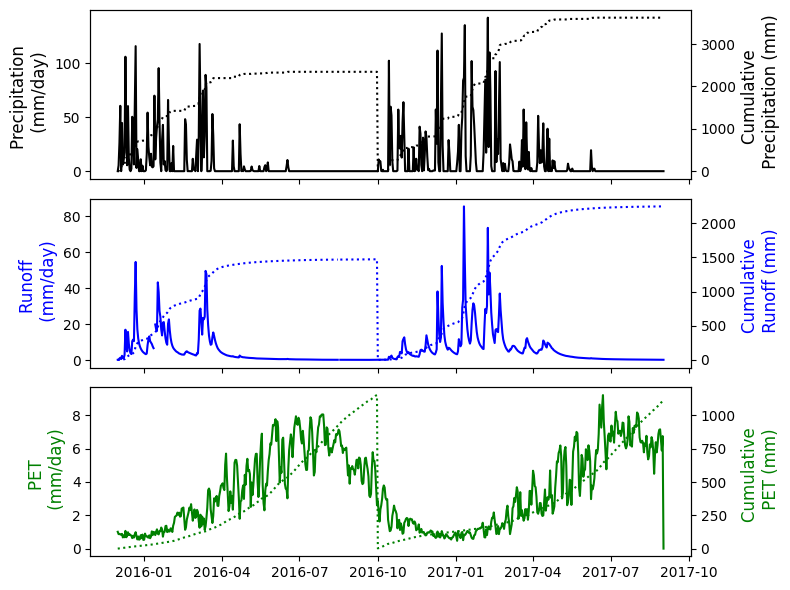

In [ ]:
# Create a figure with three subplots (one for each variable: ppt, runoff, PET)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))  # 3 rows, 1 column of subplots

# Plot for Precipitation
ax = axes[0]  # First subplot for precipitation
ax.plot(elder.index, elder.ppt, color='black')
ax.set_ylabel('Precipitation \n (mm/day)', color='black', fontsize=12)

# Twin y-axis for cumulative precipitation
ax2 = ax.twinx()
ax2.plot(elder.index, elder.cumt_wy_ppt, color='black', linestyle=':')
ax2.set_ylabel('Cumulative \n Precipitation (mm)', color='black', fontsize=12)

# Plot for Runoff
ax = axes[1]  # Second subplot for runoff
ax.plot(elder.index, elder.runoff, color='blue')
ax.set_ylabel('Runoff \n (mm/day)', color='blue', fontsize=12)

# Twin y-axis for cumulative runoff
ax2 = ax.twinx()
ax2.plot(elder.index, elder.cumt_wy_q, color='blue', linestyle=':')
ax2.set_ylabel('Cumulative \n Runoff (mm)', color='blue', fontsize=12)

# Plot for PET (Potential Evapotranspiration)
ax = axes[2]  # Third subplot for PET
ax.plot(elder.index, elder.pet, color='green')
ax.set_ylabel('PET \n (mm/day)', color='green', fontsize=12)

# Twin y-axis for cumulative PET
ax2 = ax.twinx()
ax2.plot(elder.index, elder.cumt_wy_pet, color='green', linestyle=':')
ax2.set_ylabel('Cumulative \n PET (mm)', color='green', fontsize=12)


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



### <font color= orange> Task: Replicate the above plot of P, Q, and PET, but for **Dry Creek**
- <font color = orange> HINT: look at how the x and y variables are formatted in the above code cell

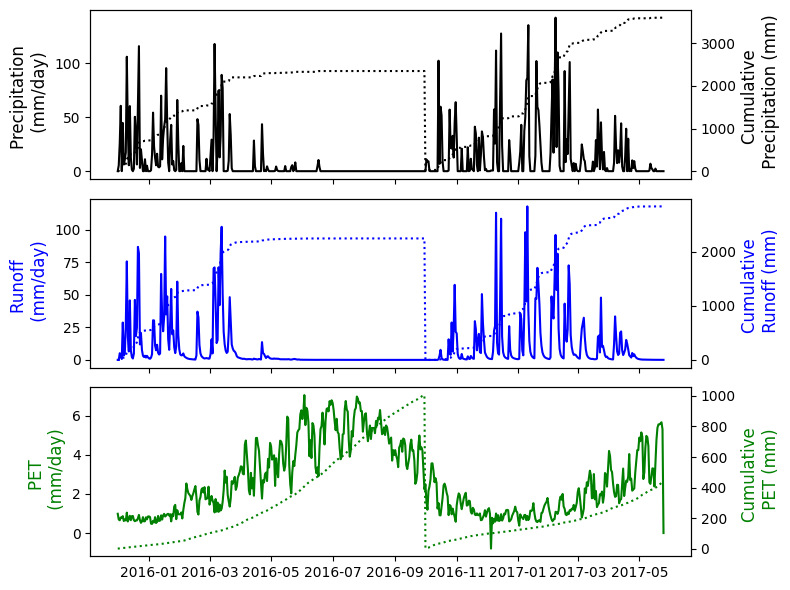

In [ ]:
# Create a figure with three subplots (one for each variable: ppt, runoff, PET)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))  # 3 rows, 1 column of subplots

# Plot for Precipitation
ax = axes[0]  # First subplot for precipitation
ax.plot(dry.index, dry.ppt, color='black')
ax.set_ylabel('Precipitation \n (mm/day)', color='black', fontsize=12)

# Twin y-axis for cumulative precipitation
ax2 = ax.twinx()
ax2.plot(dry.index, dry.cumt_wy_ppt, color='black', linestyle=':')
ax2.set_ylabel('Cumulative \n Precipitation (mm)', color='black', fontsize=12)

# Plot for Runoff
ax = axes[1]  # Second subplot for runoff
ax.plot(dry.index, dry.runoff, color='blue')
ax.set_ylabel('Runoff \n (mm/day)', color='blue', fontsize=12)

# Twin y-axis for cumulative runoff
ax2 = ax.twinx()
ax2.plot(dry.index, dry.cumt_wy_q, color='blue', linestyle=':')
ax2.set_ylabel('Cumulative \n Runoff (mm)', color='blue', fontsize=12)

# Plot for PET (Potential Evapotranspiration)
ax = axes[2]  # Third subplot for PET
ax.plot(dry.index, dry.pet, color='green')
ax.set_ylabel('PET \n (mm/day)', color='green', fontsize=12)

# Twin y-axis for cumulative PET
ax2 = ax.twinx()
ax2.plot(dry.index, dry.cumt_wy_pet, color='green', linestyle=':')
ax2.set_ylabel('Cumulative \n PET (mm)', color='green', fontsize=12)


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

We can examine what fraction of the precipitation goes to runoff vs. evapotranspiration in each watershed. **What do you expect given what you know about the two watersheds?**

<font color=red> Elder creek would be expected to have a higher runoff fraction, whereas dry creek would be expected to have a higher evapotranspiration fraction

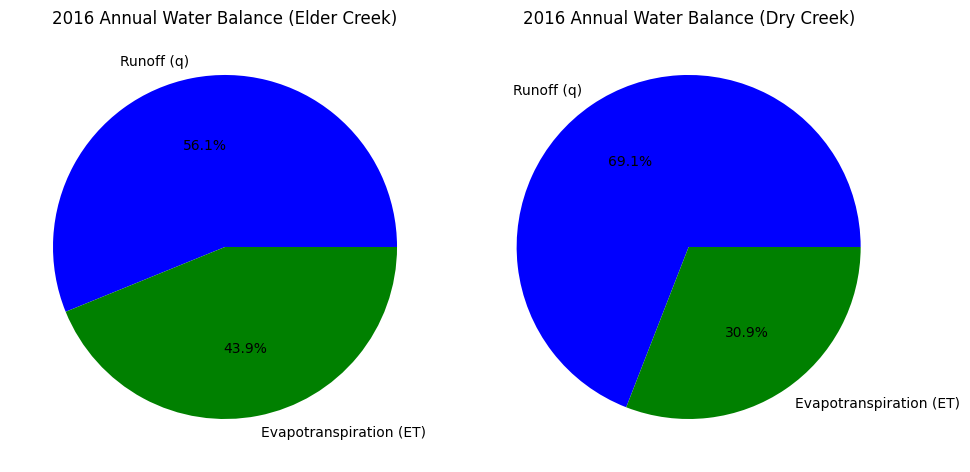

In [ ]:
# to find the total value for the year, we can just look at the difference between the annual volume of precipitation and the annual volume of runoff
# (i.e. the last value of our cumulative sum taken over the water year )

annual_total_pet_elder= elder.groupby(['wateryear'])['cumt_wy_pet'].nth([-2])
annual_total_q_elder = elder.groupby(['wateryear'])['cumt_wy_q'].nth([-2])
annual_total_ppt_elder = elder.groupby(['wateryear'])['cumt_wy_ppt'].nth([-2])

annual_total_pet_dry = dry.groupby(['wateryear'])['cumt_wy_pet'].nth([-2])
annual_total_q_dry = dry.groupby(['wateryear'])['cumt_wy_q'].nth([-2])
annual_total_ppt_dry = dry.groupby(['wateryear'])['cumt_wy_ppt'].nth([-2])

Elder_Q_2016 = annual_total_q_elder.iloc[0]
Elder_PPT_2016 = annual_total_ppt_elder.iloc[0]
Elder_PET_2016 = annual_total_pet_elder.iloc[0]

Dry_Q_2016 = annual_total_q_dry.iloc[0]
Dry_PPT_2016 = annual_total_ppt_dry.iloc[0]
Dry_PET_2016 = annual_total_pet_dry.iloc[0]

# For Elder Creek
elder_sizes = [
    Elder_Q_2016/Elder_PPT_2016,    # Use .iloc to access by position
    Elder_PET_2016/Elder_PPT_2016
]

# For Dry Creek
dry_sizes = [
   Dry_Q_2016/Dry_PPT_2016,
    Dry_PET_2016/Dry_PPT_2016
]

# Create labels for the pie chart
labels = ['Runoff (q)', 'Evapotranspiration (ET)']

# Create the pie charts
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Elder Creek pie chart
ax[0].pie(elder_sizes, labels=labels, autopct='%1.1f%%', colors=['blue', 'green'])
ax[0].set_title('2016 Annual Water Balance (Elder Creek)')

# Dry Creek pie chart
ax[1].pie(dry_sizes, labels=labels, autopct='%1.1f%%', colors=['blue', 'green'])
ax[1].set_title('2016 Annual Water Balance (Dry Creek)')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Testing assumptions: How well does PET capture ET?

Because ET is so hard to measure, we often compute it as the residual of the annual water balance, meaning that we make the assumption that there is no change in storage over the annual timescale and solve for ET.

$$0 = \sum_{\text{Oct 1, 2015}}^{\text{Oct 1, 2016}} \left(P(t) - Q(t) - ET(t)\right) $$



$$\sum_{\text{Oct 1, 2015}}^{\text{Oct 1, 2016}} ET(t) = \sum_{\text{Oct 1, 2015}}^{\text{Oct 1, 2016}} (P(t) - Q(t)) $$

Let's compare evapotranspiration computed from the water balance residual to the potential evapotranspiration (PET) reported in Dralle et al., 2018. **Do you expect PET to represent ET well at one site more than the other? Why?**

Maybe Elder Creek would have a better representation of ET because it has more vegetation and more storage

### <font color= orange> Task: Insert the equation for ET using equation above
- <font color= orange> HINT: The variables you need for your equation are already defined for you in the below code cell :)

In [ ]:
# to find the total value, we can just look at the difference between the annual volume of precipitation and the annual volume of runoff
# (i.e. the last value of our cumulative sum taken over the water year )

Elder_Q_2016 = annual_total_q_elder.iloc[0]
Elder_PPT_2016 = annual_total_ppt_elder.iloc[0]
Elder_PET_2016 = annual_total_pet_elder.iloc[0]

Dry_Q_2016 = annual_total_q_dry.iloc[0]
Dry_PPT_2016 = annual_total_ppt_dry.iloc[0]
Dry_PET_2016 = annual_total_pet_dry.iloc[0]

Dry_ET_2016 =  Dry_PPT_2016 - Dry_Q_2016
Elder_ET_2016 = Elder_PPT_2016 - Elder_Q_2016




Let's visualize your calculation with a bar graph. Do the data align with your expectations? What can you learn about these watersheds from the comparison of annual ET and PET?

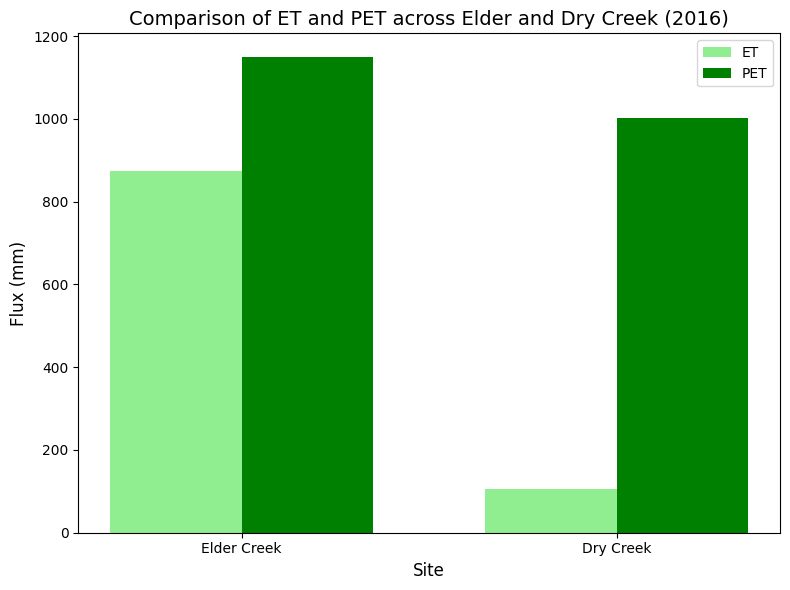

In [ ]:

# Data to plot
sites = ['Elder Creek', 'Dry Creek']
et_values = [Elder_ET_2016, Dry_ET_2016]
pet_values = [Elder_PET_2016, Dry_PET_2016]

# Define the bar width
bar_width = 0.35

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Bar positions
index = range(len(sites))

# Plot ET and PET bars side by side
et_bars = ax.bar(index, et_values, bar_width, label='ET', color='#90EE90')
pet_bars = ax.bar([i + bar_width for i in index], pet_values, bar_width, label='PET', color='green')

# Add labels, title, and legend
ax.set_xlabel('Site', fontsize=12)
ax.set_ylabel('Flux (mm)', fontsize=12)
ax.set_title('Comparison of ET and PET across Elder and Dry Creek (2016)', fontsize=14)
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(sites)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()